In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from detector import extract_features, EssayAIDetector
import pandas as pd
from get_logprobs import LMLogProbs
from get_logprobs import cross_model_disagreement
import numpy as np
import joblib
import nltk
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV
from collections import Counter
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.metrics import f1_score
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize
import re

[nltk_data] Downloading package punkt to /home/udntn/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/udntn/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


helper funct

In [12]:
from transformers import AutoTokenizer
from nltk.tokenize import sent_tokenize
import numpy as np

def sliding_window_chunks(text, chunk_size=128, stride=64):
    chunks = []

    for start in range(0, len(text), stride):
        end = start + chunk_size
        window = text[start:end]

        if len(window) < chunk_size:
            break

        chunks.append(window)

    return chunks

In [13]:
def get_token_logprobs_and_tokens(lm, text):
    device = next(lm.model.parameters()).device  # gpu or cpu

    enc = lm.tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        out = lm.model(**enc)
        logp = torch.log_softmax(out.logits, dim=-1)

    ids = enc["input_ids"][0]
    token_logps = logp[0, :-1, ids[1:]].cpu().numpy()
    token_strs = lm.tokenizer.convert_ids_to_tokens(ids[1:])

    return token_strs, token_logps


def tokens_to_word_logprobs(tokens, logps):
    words = []
    word_logps = []

    current_word = ""
    current_lps = []

    for tok, lp in zip(tokens, logps):
        # new word markers (GPT2: Ġ, SentencePiece: ▁)
        if tok.startswith("Ġ") or tok.startswith("▁"):
            if current_word:
                words.append(current_word)
                word_logps.append(np.mean(current_lps))
            current_word = tok.lstrip("Ġ▁")
            current_lps = [lp]
        else:
            current_word += tok
            current_lps.append(lp)

    if current_word:
        words.append(current_word)
        word_logps.append(np.mean(current_lps))

    return words, np.array(word_logps)

def cross_model_disagreement_word_aligned(lm_a, lm_b):

    n = min(len(lm_a), len(lm_b))
    if n == 0:
        return 0.0

    return float(np.mean(np.abs(lm_a[:n] - lm_b[:n])))


def get_chunk_word_log_probs(lm, chunk_words):
    token_ids = torch.cat(
        [lm.tokenize(w).flatten() for w in chunk_words],
        dim=0
    ).unsqueeze(0)

    token_log_probs = lm.get_log_probs(token_ids)
    tokens = lm.tokenizer.convert_ids_to_tokens(token_ids[0])
    return tokens_to_word_logprobs(tokens, token_log_probs)

In [ ]:
import os
import json

output_dir = os.path.expanduser("~/AI/ai_detector/training_data/")
os.makedirs(output_dir, exist_ok=True)

gpt2_records = []

with open(output_dir +"sentence_logprobs_gpt2_raid-v3.jsonl") as f:
    for line in f:
        gpt2_records.append(json.loads(line))


In [15]:
def extract_word_features(word_log_probs):

    log_probs = np.array(word_log_probs, dtype=np.float64)
    log_probs = np.clip(log_probs, -50, 0)  # clip extreme negatives

    if len(log_probs) == 0:
        return np.zeros(9, dtype=np.float64)

    # sequence-level perplexity (length-normalized)
    seq_ppl = np.exp(-np.mean(log_probs))

    # basic stats
    sum_lp = np.sum(log_probs)
    mean_lp = np.mean(log_probs)
    std_lp = np.std(log_probs)
    var_lp = np.var(log_probs)
    min_lp = np.min(log_probs)
    max_lp = np.max(log_probs)

    # burstiness (optional)
    burstiness = var_lp

    # length-normalized per-token PPL stats
    mean_ppl = seq_ppl           # already averaged
    var_ppl = np.var(np.exp(-log_probs))  # variance, optional
    std_ppl = np.sqrt(var_ppl)

    return np.array([
        mean_lp,
        sum_lp,
        var_lp,
        std_lp,
        min_lp,
        max_lp,
        burstiness,
        mean_ppl,
        std_ppl
    ], dtype=np.float64)

def get_perplexity(log_probs):
    log_probs = np.array(log_probs, dtype=np.float64)
    return np.exp(-(log_probs))

def chunk_sentences(text, k=1):
    sentences = split_sentences_max_words(text)
    return [" ".join(sentences[i:i+k]) 
            for i in range(0, len(sentences), k)]

from collections import Counter

def sentence_stats_features(sentence):
    """
    Compute aggregate sentence-level stats for a list of sentences.
    
    Returns:
        [mean_len, std_len, mean_rep, max_rep]
    """
    lengths = []
    rep_counts = []

    word_lengths = []

    
    words = sentence.split()

    if len(words) == 0:
        # fallback for empty input
        return np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

    for word in words:
        word_lengths.append(len(word))

    lengths.append(len(words))

    counts = list(Counter(words).values())

    #mean_len = float(np.mean(lengths))
    #std_len = float(np.std(lengths))
    mean_rep = float(np.mean(counts))
    max_rep = float(np.max(counts))
    #word_len = float(np.mean(word_lengths))
    max_len = float(np.max(word_lengths))
    min_len = float(np.min(word_lengths))
    word_std = float(np.std(word_lengths))
    word_var = float(np.var(word_lengths))

    return np.array([mean_rep, max_rep, max_len, min_len, word_std, word_var])

def make_sentence_chunks(text, window=4, stride=2):
    sentences = split_sentences_max_words(text)
    chunks = []
    if len(sentences) <= window:
        return [" ".join(sentences)]
    
    for i in range(0, len(sentences) - window + 1, stride):
        chunk = " ".join(sentences[i:i+window])
        chunks.append(chunk)
    return chunks

from collections import Counter
import numpy as np

def compute_stats_features(sentence):
    """
    Compute repetition statistics for a sentence.
    Returns: [mean_repeat, max_repeat, min_repeat] over words.
    """

    words = sentence.split()  # tokenize by whitespace
    if len(words) == 0:
        return np.array([0.0, 0.0, 0.0], dtype=np.float32)

    counts = list(Counter(words).values())  # how many times each word appears

    mean_rep = np.mean(counts)
    max_rep = np.max(counts)
    min_rep = np.min(counts)

    return np.array([mean_rep, max_rep, min_rep], dtype=np.float32)

def cross_model_disagreement_3(lp_a, lp_b, lp_c):
    if len(lp_a)==0 or len(lp_b)==0 or len(lp_c)==0:
        return 0.0

    n = min(len(lp_a), len(lp_b), len(lp_c))
    a = lp_a[:n]
    b = lp_b[:n]
    c = lp_c[:n]

    # normalize each model
    def norm(x):
        return (x - np.mean(x)) / (np.std(x) + 1e-8)

    a = norm(a)
    b = norm(b)
    c = norm(c)

    dab = np.mean(np.abs(a - b))
    dac = np.mean(np.abs(a - c))
    dbc = np.mean(np.abs(b - c))

    return float((dab + dac + dbc) / 3.0)

def get_burstiness(log_probs, window_size=5):

    lp = log_probs
    n = len(lp)
    if n < 2:
        return 0.0
    # sliding window means
    means = []
    for start in range(0, n - window_size + 1):
        window = lp[start:start+window_size]
        if len(window) > 0:
            means.append(np.mean(window))
    return float(np.std(means)) if len(means) > 1 else 0.0


def split_sentences_max_words(text, max_words=100):
    sentences = sent_tokenize(text)
    chunks = []

    for sent in sentences:
        words = sent.split()

        if len(words) <= max_words:
            chunks.append(sent)
        else:
            # split long sentence only\n",
            for i in range(0, len(words), max_words):
                chunks.append(" ".join(words[i:i+max_words]))

    return chunks

In [2]:
lm_models = {
    "gpt2": LMLogProbs("gpt2-medium"),
    #"pythia": LMLogProbs("EleutherAI/pythia-410m"),
    #"distil": LMLogProbs("distilgpt2")
    #"neo": LMLogProbs("EleutherAI/gpt-neo-1.3B")
}

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
#data = pd.read_csv("../datasets/ai-ga-dataset.csv")
#data2 = pd.read_csv("../datasets/AI-vs-Human-2500.csv", encoding='latin-1')
##data3 = pd.read_csv("../datasets/AI_Human.csv")
##data4 = pd.read_csv("../datasets/AI_Generated_Essays_Dataset.csv")
#data5 = pd.read_excel("../datasets/AIGTxt.xlsx")
#data5 = pd.read_excel("../datasets/AIGTxt.xlsx")
##raid = pd.read_csv("../datasets/train.csv")
#
#text = []
#
#for _, row in tqdm(data.iterrows(), total=len(data)):
#	text.append((row["abstract"], row["label"]))
#     
#for _, row in tqdm(data2.iterrows(), total=len(data2)):
#	txt = row["text"]
#	if isinstance(txt, str):
#		text.append((txt, 1 if str(row["label"]).lower() == "fake" else 0))
#          
#for _, row in tqdm(data3.iterrows(), total=len(data3)):
#	text = str(row["generation"])
#
#	text.append((row["text"], row["generated"]))
#

#for _, row in tqdm(data4.iterrows(), total=len(data4)):
#	text.append((row["text"], row["generated"]))
#	
#for _, row in tqdm(data5.iterrows(), total=len(data5)):
#	text.append((row["Human-Generated"], 0))
#	text.append((row["ChatGPT-Generated"], 1))
	



output_dir = os.path.expanduser("~/AI/datasets/")
os.makedirs(output_dir, exist_ok=True)

# Paths
text_dataset_path = os.path.join(output_dir, "combined_balanced.jsonl")

text_dataset = pd.read_json(text_dataset_path, lines=True)


# Combine datasets
text_dataset = pd.DataFrame(text_dataset)

print("Before cleaning:", len(text_dataset))

# ---------------- Clean text ----------------
def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"[\u0000-\u001F\u007F-\u009F]", "", s)      # control chars
    s = re.sub(r"[\u200B-\u200D\uFEFF]", "", s)            # zero-width
    s = re.sub(r"\s+", " ", s).strip()
    return s

def is_junk(s):
    if len(s) < 5:
        return True

    letters = len(re.findall(r"\p{L}", s))
    digits  = len(re.findall(r"\p{N}", s))
    spaces  = len(re.findall(r"\p{Zs}", s))
    total   = len(s)

    language_ratio = (letters + digits + spaces) / total

    if "�" in s:
        return True
    if language_ratio < 0.6:
        return True

    return False

# Apply cleaning
text_dataset["generation"] = text_dataset["generation"].apply(clean_text)

# Detect junk
text_dataset["is_junk"] = text_dataset["generation"].apply(is_junk)
print("Junk rate:", text_dataset["is_junk"].mean())

# Drop junk only
text_dataset = text_dataset[~text_dataset["is_junk"]].reset_index(drop=True)
text_dataset = text_dataset.drop(columns=["is_junk"])

print("After cleaning:", len(text_dataset))

count = 0
for row in tqdm(text_dataset.itertuples(index=False), total=len(text_dataset)):
    sentences = split_sentences_max_words(row.generation)
    for s in sentences:
        count = count +1

print(count)







Before cleaning: 26450
Junk rate: 0.00041587901701323253
After cleaning: 26439


  0%|          | 0/26439 [00:00<?, ?it/s]


NameError: name 'split_sentences_max_words' is not defined

In [30]:
import os
import pandas as pd
import unicodedata
import regex as re
import json

gpt2_records = []

old_lookup = {}

output_dir = os.path.expanduser("~/AI/datasets/cheat_dataset/")
os.makedirs(output_dir, exist_ok=True)


with open(output_dir + "ieee-init.jsonl") as f:
    for line in f:
        gpt2_records.append(json.loads(line))

with open(output_dir + "ieee-chatgpt-generation.jsonl") as f:
    for line in f:
        gpt2_records.append(json.loads(line))

output_dir = os.path.expanduser("~/AI/ai_detector/training_data/")
os.makedirs(output_dir, exist_ok=True)


with open(output_dir + "sentence_logprobs_gpt2-cheat-v6.jsonl") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        old_lookup[rec["text"]] = rec


    

import os

output_dir = os.path.expanduser("~/AI/ai_detector/training_data/")
os.makedirs(output_dir, exist_ok=True)


# Open JSONL files for each model
sentence_out = open(output_dir + "sentence_logprobs_gpt2_cheat_essayNum.jsonl", "w")

count = 0
for row in tqdm(gpt2_records, total=len(gpt2_records)):
    count += 1
    essay = row["abstract"]

    sentences = split_sentences_max_words(essay)

    for sent in sentences:
        if  sent in old_lookup:
            row = old_lookup[sent]
            record = {
                "text": sent,
                "essayNum": count,
                "model": "gpt2",
                "label": row["label"],
                "word_log_probs": row["word_log_probs"],
                "mean": row["mean"],
                "std": row["std"]
            }
            sentence_out.write(json.dumps(record) + "\n")
sentence_out.close()

100%|██████████| 30790/30790 [00:07<00:00, 3948.86it/s]


In [10]:
import json
import random


human_file = os.path.join(output_dir, "raid_human_balanced-v2.jsonl")
ai_file = os.path.join(output_dir, "raid_AI_balanced-v2.jsonl")
out_file = os.path.join(output_dir, "combined_balanced.jsonl")

# ------------------
# Load both
# ------------------
with open(human_file) as f:
    human = [json.loads(l) for l in f]

with open(ai_file) as f:
    ai = [json.loads(l) for l in f]

print("Human:", len(human))
print("AI:", len(ai))

# ------------------
# Balance
# ------------------
N = min(len(human), len(ai))

human = random.sample(human, N)
ai    = random.sample(ai, N)

# ------------------
# Combine + shuffle
# ------------------
combined = human + ai
random.shuffle(combined)

# ------------------
# Save
# ------------------
with open(out_file, "w") as f:
    for row in combined:
        f.write(json.dumps(row) + "\n")

print("Final dataset:", len(combined))

Human: 13225
AI: 32777
Final dataset: 26450


In [5]:
from tqdm import tqdm

cheat_datset = pd.read_excel("../datasets/cheat_dataset/ieee-init.xlsx")

cheat_gpt_datset = pd.read_excel("../datasets/cheat_dataset/ieee-chatgpt-generation.xlsx")

text = []

for _, row in tqdm(cheat_datset.iterrows(), total=len(cheat_datset)):
    text.append((row["abstract"], 0))
for _, row in tqdm(cheat_gpt_datset.iterrows(), total=len(cheat_gpt_datset)):
    text.append((row["abstract"], 1))

text_dataset = pd.DataFrame(text)


100%|██████████| 15395/15395 [00:00<00:00, 25143.72it/s]


In [4]:
import os
print(os.getcwd())

/home/udntn/AI/ai_detector


In [1]:
import pandas as pd
INPUT_FILE = "../datasets/train.csv"
df = pd.read_csv(INPUT_FILE)

In [4]:
import pandas as pd
import json
import random
from collections import defaultdict
from tqdm import tqdm

INPUT_FILE = "../datasets/train.csv"
OUTPUT_FILE = "raid_AI_balanced-v2.jsonl"
TARGET_TOTAL = 50_000

# -----------------------------
# Bucketing helpers
# -----------------------------
def length_bucket(text):
    n = len(text.split())
    if n < 50:
        return "short"
    elif n < 200:
        return "medium"
    else:
        return "long"
def model_type(text):
    p = str(text).lower()
    if 'chatgpt' in p:
        return "chatgpt"
    if 'gpt4' in p:
        return 'gpt4'
    if 'gpt3' in p:
        return 'gpt3'
    if 'gpt2' in p:
        return 'gpt2'
    else:
        return 'nothing'


def prompt_type(prompt):
    p = str(prompt).lower()
    if "book" in p:
        return "book"
    if "abstract" in p:
        return "abstract"
    if "poem" in p:
        return "poem"
    if "news" in p:
        return "news"
    if "reddit" in p:
        return "reddit"
    if "reviews" in p:
        return "reviews"
    if "wiki" in p:
        return "wiki"
    return "other"

# -----------------------------
# Load CSV
# -----------------------------


buckets = defaultdict(list)

for _, row in tqdm(df.iterrows(), total=len(df)):
    text = str(row["generation"])
    prompt = str(row["domain"])
    model = model_type(str(row["model"]))
    attack = str(row["attack"])
    if model == "nothing":
        continue
    if attack != "none":
        continue
    key = (prompt_type(prompt), length_bucket(text), model)
    buckets[key].append(row.to_dict())

print("Total buckets:", len(buckets))

# -----------------------------
# Balanced sampling
# -----------------------------
keys = list(buckets.keys())
random.shuffle(keys)

per_bucket = TARGET_TOTAL // len(keys)
print("Per bucket target:", per_bucket)

sampled = []

for k in keys:
    pool = buckets[k]
    if len(pool) <= per_bucket:
        sampled.extend(pool)
    else:
        sampled.extend(random.sample(pool, per_bucket))

random.shuffle(sampled)
sampled = sampled[:TARGET_TOTAL]

# -----------------------------
# Write JSONL
# -----------------------------
with open(OUTPUT_FILE, "w") as out:
    for row in sampled:
        out.write(json.dumps(row) + "\n")

print("Saved:", len(sampled), "to", OUTPUT_FILE)


  0%|          | 0/5615820 [00:00<?, ?it/s]

100%|██████████| 5615820/5615820 [04:05<00:00, 22902.00it/s]


Total buckets: 74
Per bucket target: 675
Saved: 32777 to raid_AI_balanced-v2.jsonl


In [6]:
import pandas as pd
import torch
import json
from tqdm import tqdm
from itertools import chain
import os

# -----------------------------
# Settings
# -----------------------------
BATCH_SIZE = 16       # Number of sentences per batch
MAX_TOKENS = 1024     # Max tokens per sentence
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
window = 4

for model_name, lm in lm_models.items():
    if lm.tokenizer.pad_token is None:
        lm.tokenizer.pad_token = lm.tokenizer.eos_token
    lm.model.to(DEVICE)
    lm.model.half()
    lm.model.eval()

# -----------------------------
# Load data
# -----------------------------
#data3 = pd.read_csv("../datasets/AI_Human.csv")
#text_dataset = data3[["text", "generated"]].copy()

# -----------------------------
# Helper functions
# -----------------------------

def get_batch_token_logprobs_and_tokens(lm, texts, max_length=MAX_TOKENS):
    enc = lm.tokenizer(
        texts,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=max_length
    ).to(DEVICE)

    input_ids = enc["input_ids"]
    attention_mask = enc["attention_mask"]
    lm.model.eval()

    out = lm.model(input_ids=input_ids, attention_mask=attention_mask)
    log_probs = torch.nn.functional.log_softmax(out.logits, dim=-1)
    token_logps = log_probs.gather(
        2, input_ids[:, 1:].unsqueeze(-1)
    ).squeeze(-1)

    lengths = attention_mask.sum(dim=1) - 1

    results = []
    for i in range(len(texts)):
        L = lengths[i].item()
        toks = lm.tokenizer.convert_ids_to_tokens(input_ids[i, 1:L+1])
        lps = token_logps[i, :L].cpu().numpy()
        results.append((toks, lps))

    return results

import os

output_dir = os.path.expanduser("~/AI/ai_detector/training_data/")
os.makedirs(output_dir, exist_ok=True)


# Open JSONL files for each model
sentence_dict = {
    "gpt2": open(output_dir + "sentence_logprobs_gpt2_raid-v3.jsonl", "w"),
    #"pythia": open(output_dir + "sentence_logprobs_pythia_raid.jsonl", "w")
}
#chunk_dict = {
#    "gpt2": open(output_dir + "chunk_logprobs_gpt2_AI_Human.jsonl", "w"),
#    #"pythia": open(output_dir + "chunk_logprobs_pythia_AI_Human.jsonl", "w")
#}
with torch.no_grad():
    with torch.cuda.amp.autocast():
        count = 0
        for row in tqdm(text_dataset.itertuples(index=False), total=len(text_dataset)):
            count = count + 1
            essay = row.generation
            if row.model == "human":
                label = 0
            else:
                label = 1

            # Split essay into sentences
            sentences = split_sentences_max_words(essay)

            # Process in batches
        # ---------- SENTENCE RECORDS ----------

            for i in range(0, len(sentences), BATCH_SIZE):
                for model_name, lm in lm_models.items():

                    batch_sentences = sentences[i:i+BATCH_SIZE]

                    results = get_batch_token_logprobs_and_tokens(lm, batch_sentences)

                    for sent, (tokens, logps) in zip(batch_sentences, results):
                        if len(logps) == 0:
                            continue

                        record = {
                            "text": sent,
                            "essayNum":count,
                            "model": model_name,
                            "label": label,
                            "word_log_probs": logps.tolist(),
                            "mean": float(np.mean(logps)),
                            "std": float(np.std(logps))
                        }

                        sentence_dict[model_name].write(json.dumps(record) + "\n")


            # ---------- CHUNK RECORDS ----------
            # build chunks ONCE
            #if len(sentences) <= window:
            #    chunks = [" ".join(sentences)]
            #else:
            #    chunks = []
            #    for j in range(0, len(sentences) - window + 1, 1):
            #        chunks.append(" ".join(sentences[j:j+window]))
#
            #for i in range(0, len(chunks), BATCH_SIZE):
            #    batch_chunks = chunks[i:i+BATCH_SIZE]
#
            #    for model_name, lm in lm_models.items():
            #        results = get_batch_token_logprobs_and_tokens(lm, batch_chunks)
#
            #        for chunk_text, (tokens, logps) in zip(batch_chunks, results):
            #            if len(logps) == 0:
            #                continue
#
            #            record = {
            #                "text": chunk_text,
            #                "essayNum":count,
            #                "model": model_name,
            #                "label": label,
            #                "word_log_probs": logps.tolist(),
            #                "mean": float(np.mean(logps)),
            #                "std": float(np.std(logps))
            #            }
#
            #            chunk_dict[model_name].write(json.dumps(record) + "\n")

        # Close files
    for f in sentence_dict.values():
        f.close()

/tmp/ipykernel_889/4130795484.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 26439/26439 [5:30:45<00:00,  1.33it/s]   


In [ ]:
import json
from tqdm import tqdm

outfile = open("sentence_logprobs_gpt2-cheat.jsonl", "w")
outfile2 = open("sentence_logprobs_pythia-cheat.jsonl", "w")

for row in tqdm(text_dataset.itertuples(index=False), total=len(text_dataset)):   # (essay, label)
    essay = row[0]
    label = row[1]
    
    sentences = split_sentences_max_words(essay)

    for name, lm in lm_models.items():
        for sent in sentences:
            if len(lm.tokenize(sent)) >= 1024:
                continue

            tokens, token_log_probs = get_token_logprobs_and_tokens(lm, sent)
            word_strs, word_log_probs = tokens_to_word_logprobs(tokens, token_log_probs)

            if len(word_log_probs) == 0:
                continue

            record = {
                "model": name,
                "label": int(label),
                "sentence": sent,
                "word_log_probs": word_log_probs.tolist(),
                "words": word_strs
            }
            if(name == "gpt2"):
                outfile.write(json.dumps(record) + "\n")
            else:
                outfile2.write(json.dumps(record) + "\n")
                
            

outfile.close()

100%|██████████| 43194/43194 [3:32:27<00:00,  3.39it/s]   


In [30]:
import json
from tqdm import tqdm

output_dir = os.path.expanduser("~/Desktop/AI/ai_detector/output")
os.makedirs(output_dir, exist_ok=True)

gpt2_file = os.path.join(output_dir, "chunk_logprobs_gpt2-cheat.jsonl")
pythia_file = os.path.join(output_dir, "chunk_logprobs_pythia-cheat.jsonl")

out_gpt2 = os.path.join(output_dir, "chunk_logprobs_gpt2_aligned-cheat.jsonl")
out_pythia = os.path.join(output_dir, "chunk_logprobs_pythia_aligned-cheat.jsonl")

# --- load GPT2 ---
gpt2_map = {}
with open(gpt2_file, "r") as f:
    for line in tqdm(f, desc="Loading GPT2"):
        rec = json.loads(line)
        gpt2_map[rec["text"]] = rec

# --- load Pythia ---
pythia_map = {}
with open(pythia_file, "r") as f:
    for line in tqdm(f, desc="Loading Pythia"):
        rec = json.loads(line)
        pythia_map[rec["text"]] = rec

# --- intersection ---
common_sentences = list(set(gpt2_map.keys()) & set(pythia_map.keys()))
print("Common sentences:", len(common_sentences))

# --- write aligned files ---
with open(out_gpt2, "w") as f1, open(out_pythia, "w") as f2:
    for sent in tqdm(common_sentences, desc="Writing aligned"):
        f1.write(json.dumps(gpt2_map[sent]) + "\n")
        f2.write(json.dumps(pythia_map[sent]) + "\n")

print("✅ Done")
print("Wrote:")
print(out_gpt2)
print(out_pythia)

Loading GPT2: 114971it [00:06, 17643.14it/s]
Loading Pythia: 114971it [00:06, 18385.79it/s]


Common sentences: 114959


Writing aligned: 100%|██████████| 114959/114959 [00:23<00:00, 4966.61it/s]

✅ Done
Wrote:
/home/udntn/Desktop/AI/ai_detector/output/chunk_logprobs_gpt2_aligned-cheat.jsonl
/home/udntn/Desktop/AI/ai_detector/output/chunk_logprobs_pythia_aligned-cheat.jsonl


In [24]:
import json
from tqdm import tqdm


outfile = open("chunk_logprobs_gpt2.jsonl", "w")
outfile2 = open("chunk_logprobs_pythia.jsonl", "w")

for row in tqdm(text_dataset.itertuples(index=False), total=len(text_dataset)):   # (essay, label)
    essay = row[0]
    label = row[1]
    
    chunks = make_sentence_chunks(essay, window=4, stride=2)
    
    for name, lm in lm_models.items():
        for chunk in chunks:
            if len(lm.tokenize(chunk)) >= 1024:
                print("chunk too big")
                continue

            tokens, token_log_probs = get_token_logprobs_and_tokens(lm, chunk)
            word_strs, word_log_probs = tokens_to_word_logprobs(tokens, token_log_probs)

            if len(word_log_probs) == 0:
                continue

            record = {
                "words": chunk,
                "model":name,
                "label":label,
                "word_log_probs": word_log_probs.tolist(),
                "mean": float(np.mean(word_log_probs)),
                "std": float(np.std(word_log_probs))
            }

            if(name == "gpt2"):
                outfile.write(json.dumps(record) + "\n")
            else:
                outfile2.write(json.dumps(record) + "\n")

outfile.close()

100%|██████████| 43194/43194 [1:25:20<00:00,  8.44it/s]  


In [ ]:
import json
from tqdm import tqdm

lm = LMLogProbs("EleutherAI/gpt-neo-1.3B")

outfile = open("sentence_logprobs_neo.jsonl", "w")

for row in tqdm(text_dataset.itertuples(index=False), total=len(text_dataset)):   # (essay, label)
    essay = row[0]
    label = row[1]
    
    sentences = split_sentences_max_words(essay)

    for sent in sentences:
        if len(lm.tokenize(sent)) >= 1024:
            continue

        tokens, token_log_probs = get_token_logprobs_and_tokens(lm, sent)
        word_strs, word_log_probs = tokens_to_word_logprobs(tokens, token_log_probs)

        if len(word_log_probs) == 0:
            continue

        record = {
            "model": "gpt-neo-1.3B",
            "label": int(label),
            "sentence": sent,
            "word_log_probs": word_log_probs.tolist(),
            "words": word_strs
        }

        outfile.write(json.dumps(record) + "\n")

outfile.close()

  0%|          | 18/43194 [00:33<22:04:21,  1.84s/it]


KeyboardInterrupt: 

In [9]:
import os
import json

pythia_records = []
gpt2_records = []

output_dir = os.path.expanduser("~/Desktop/AI/ai_detector/output")
os.makedirs(output_dir, exist_ok=True)


with open("sentence_logprobs_gpt2_aligned.jsonl") as f:
    for line in f:
        pythia_records.append(json.loads(line))

#with open("sentence_logprobs_pythia_big_aligned.jsonl", "r") as f:
#    for line in f:
#        pythia_records.append(json.loads(line))

with open("sentence_logprobs_pythia_aligned.jsonl") as f:
    for line in f:
        gpt2_records.append(json.loads(line))

#with open(os.path.join(output_dir, "sentence_logprobs_gpt2_big_aligned.jsonl"), "r") as f:
#    for line in f:
#        gpt2_records.append(json.loads(line))




In [11]:
import json
import os

pythia_chunks = []
gpt2_chunks = []


with open("chunks_logprobs_pythia_aligned.jsonl") as f:
    for line in f:
        pythia_chunks.append(json.loads(line))

with open("chunks_logprobs_gpt2_aligned.jsonl") as f:
    for line in f:
        gpt2_chunks.append(json.loads(line))


In [12]:
import pandas as pd

pythia_chunks = pd.DataFrame(pythia_chunks)

# data cleansing
print(len(pythia_chunks))
pythia_chunks = pythia_chunks[pythia_chunks["text"].str.len() > 30]
print(len(pythia_chunks))
pythia_chunks = pythia_chunks.drop_duplicates(subset="text")
print(len(pythia_chunks))

pythia_chunks["len"] = pythia_chunks["text"].str.split().apply(len)

human = pythia_chunks[pythia_chunks.label == 0]
ai    = pythia_chunks[pythia_chunks.label == 1]

min_len = max(human.len.quantile(0.05), ai.len.quantile(0.05))
max_len = min(human.len.quantile(0.95), ai.len.quantile(0.95))

pythia_chunks = pythia_chunks[(pythia_chunks.len >= min_len) & (pythia_chunks.len <= max_len)]

pythia_chunks.label.value_counts()

print(len(pythia_chunks))


gpt2_chunks = pd.DataFrame(gpt2_chunks)

# data cleansing
print(len(gpt2_chunks))
gpt2_chunks = gpt2_chunks[gpt2_chunks["text"].str.len() > 30]
print(len(gpt2_chunks))
gpt2_chunks = gpt2_chunks.drop_duplicates(subset="text")
print(len(gpt2_chunks))

gpt2_chunks["len"] = gpt2_chunks["text"].str.split().apply(len)

human = gpt2_chunks[gpt2_chunks.label == 0]
ai    = gpt2_chunks[gpt2_chunks.label == 1]

min_len = max(human.len.quantile(0.05), ai.len.quantile(0.05))
max_len = min(human.len.quantile(0.95), ai.len.quantile(0.95))

gpt2_chunks = gpt2_chunks[(gpt2_chunks.len >= min_len) & (gpt2_chunks.len <= max_len)]

gpt2_chunks.label.value_counts()

print(len(gpt2_chunks))



227947
227941
227941
180676
227947
227941
227941
180676


In [13]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.utils import shuffle
import joblib

In [14]:
def get_features(pythia_rec, gpt2_rec):   

    gpt2_sent = gpt2_rec.text

    gpt2_log_prob = gpt2_rec.word_log_probs
    pythia_log_prob = pythia_rec.word_log_probs
    # skip very short junk
    if len(gpt2_sent) < 5:
        return np.zeros(8, dtype=np.float64)

    if len(gpt2_log_prob) == 0 or len(gpt2_log_prob) == 0:
        return np.zeros(8, dtype=np.float64)

    sentences = split_sentences_max_words(gpt2_sent)
    sent_feats =[]
    for s in sentences:
        sent_feats.append(sentence_stats_features(s))
    sent_feats = np.vstack(sent_feats)
    sent_feats = np.mean(sent_feats, axis=0)    


    if len(gpt2_log_prob) == 0:
        return np.zeros(8, dtype=np.float64)

    # ---------- GPT2 features ----------
    gpt2_base = extract_word_features(gpt2_log_prob)
    #gpt2_intra = np.clip(np.var(gpt2_log_prob), 0, 5)
    #gpt2_burst = np.clip(get_burstiness(gpt2_log_prob), 0, 5)
    gpt2_feats = np.concatenate([gpt2_base])

    pythia_base = extract_word_features(pythia_log_prob)
    #pythia_intra = np.clip(np.var(pythia_log_prob), 0, 5)
    #pythia_burst = np.clip(get_burstiness(pythia_log_prob), 0, 5)
    pythia_feats = np.concatenate([pythia_base])
    pythia_perplexity = get_perplexity(pythia_log_prob)
    gpt2_perplexity = get_perplexity(gpt2_log_prob)


    disagree_val = cross_model_disagreement(pythia_perplexity, gpt2_perplexity)

    return np.concatenate([
        gpt2_feats,
        pythia_feats,
        [disagree_val],
        sent_feats
    ])

In [15]:
print("Computing features...")

x =[]
y = []

for pythia_rec, gpt2_rec in tqdm(
    zip(pythia_chunks.itertuples(index=False),
        gpt2_chunks.itertuples(index=False)),
    total=min(len(gpt2_chunks), len(gpt2_chunks))
):
    
    if gpt2_rec.text != pythia_rec.text:
        print("misaligned!")
        break
    
    gpt2_label = gpt2_rec.label
    results = get_features(pythia_rec, gpt2_rec)
    if results.all() == 0:
        continue

    x.append(results)
    y.append(gpt2_label)

import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, f1_score, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils import shuffle

# -----------------------------
# Prepare data
# -----------------------------
x = np.vstack(x)
y = np.array(y)

x, y = shuffle(x, y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Scaling (better for heavy tails)
# -----------------------------
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler_chunk_rf-v2.joblib")

# -----------------------------
# Random Forest (less overfit)
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    min_samples_leaf=5,
    min_samples_split=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

# -----------------------------
# Calibrate probabilities
# -----------------------------
cal = CalibratedClassifierCV(
    rf,
    method="isotonic",   # try "sigmoid" if isotonic overfits
    cv=5
)

cal.fit(X_train_scaled, y_train)

joblib.dump(cal, "chunk_rf_detector_calibrated-v2.joblib")

# -----------------------------
# Evaluation
# -----------------------------
y_pred = cal.predict(X_test_scaled)
y_proba = cal.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Human", "AI"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# Threshold selection (NO leakage)
# -----------------------------
thresholds = np.linspace(0.05, 0.95, 181)
best_t, best_f1 = 0.5, 0

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Chosen threshold:", best_t)
print("Best F1:", best_f1)

# Save threshold
with open("chunk_threshold.txt", "w") as f:
    f.write(str(best_t))


Computing features...


100%|██████████| 180676/180676 [01:50<00:00, 1635.92it/s]


Accuracy: 0.8404317144043172
ROC AUC: 0.8908674250869968
PR AUC: 0.8251529384130961

Classification Report:
              precision    recall  f1-score   support

       Human       0.85      0.93      0.89     24857
          AI       0.81      0.64      0.72     11278

    accuracy                           0.84     36135
   macro avg       0.83      0.79      0.80     36135
weighted avg       0.84      0.84      0.83     36135


Confusion Matrix:
[[23126  1731]
 [ 4035  7243]]
Chosen threshold: 0.35999999999999993
Best F1: 0.7314084196605687


In [43]:
import pandas as pd

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_scaled, columns=feature_names)

weak_features = [
    "disagree", "gpt2_permean",
    "pythia_loglen", "pythia_pervar",
    "gpt2_logvar", "gpt2_burst",
    "gpt2_perstd", "gpt2_perpsum"
    ]

# Drop weak features
X_train_pruned = X_train_df.drop(columns=weak_features, errors="ignore")
X_test_pruned  = X_test_df.drop(columns=weak_features, errors="ignore")

# Retrain RF
rf_model.fit(X_train_pruned, y_train)
y_proba = rf_model.predict_proba(X_test_pruned)[:,1]

from sklearn.metrics import roc_auc_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC (pruned):", roc_auc_score(y_test, y_proba))

Accuracy: 0.8862828713574982
ROC AUC (pruned): 0.957400319475066


In [16]:
import pandas as pd

pythia_records = pd.DataFrame(pythia_records)

# data cleansing
print(len(pythia_records))
pythia_records = pythia_records[pythia_records["text"].str.len() > 30]
print(len(pythia_records))
pythia_records = pythia_records.drop_duplicates(subset="text")
print(len(pythia_records))

pythia_records["len"] = pythia_records["text"].str.split().apply(len)

human = pythia_records[pythia_records.label == 0]
ai    = pythia_records[pythia_records.label == 1]

min_len = max(human.len.quantile(0.05), ai.len.quantile(0.05))
max_len = min(human.len.quantile(0.95), ai.len.quantile(0.95))

pythia_records = pythia_records[(pythia_records.len >= min_len) & (pythia_records.len <= max_len)]

pythia_records.label.value_counts()

print(len(pythia_records))



351731
347811
347811
290028


In [17]:
import pandas as pd

gpt2_records = pd.DataFrame(gpt2_records)

# data cleansing
print(len(gpt2_records))
gpt2_records = gpt2_records[gpt2_records["text"].str.len() > 30]
print(len(gpt2_records))
gpt2_records = gpt2_records.drop_duplicates(subset="text")
print(len(gpt2_records))

gpt2_records["len"] = gpt2_records["text"].str.split().apply(len)

human = gpt2_records[gpt2_records.label == 0]
ai    = gpt2_records[gpt2_records.label == 1]

min_len = max(human.len.quantile(0.05), ai.len.quantile(0.05))
max_len = min(human.len.quantile(0.95), ai.len.quantile(0.95))

gpt2_records = gpt2_records[(gpt2_records.len >= min_len) & (gpt2_records.len <= max_len)]

gpt2_records.label.value_counts()

print(len(gpt2_records))

351731
347811
347811
290028


In [ ]:
print("Computing features...")

x =[]
y = []

for pythia_rec, gpt2_rec in tqdm(
    zip(pythia_records.itertuples(index=False),
        gpt2_records.itertuples(index=False)),
    total=min(len(pythia_records), len(gpt2_records))
):
    if gpt2_rec.text != pythia_rec.text:
        print("misaligned!")
        break
    
    gpt2_label = gpt2_rec.label
    results = get_features(pythia_rec, gpt2_rec)
    if results.all() == 0:
        continue

    x.append(results)
    y.append(gpt2_label)

    #if gpt2_rec.text != pythia_rec.text:
    #    print("misaligned!")
    #    break
#
    #model_features = {}
    #all_word_log_probs_dict = {}
#
    #gpt2_sent = gpt2_rec.text
    #gpt2_label = gpt2_rec.label
#
    #gpt2_log_prob = np.array(gpt2_rec.word_log_probs)
    #pythia_log_prob = np.array(pythia_rec.word_log_probs)
    ## skip very short junk
    #if len(gpt2_sent) < 5:
    #    continue
#
    #if len(gpt2_log_prob) == 0 or len(gpt2_log_prob) == 0:
    #    continue
    #
    #sent_feats = sentence_stats_features(gpt2_sent)
#
    #if len(gpt2_log_prob) == 0:
    #    continue
#
    ## ---------- GPT2 features ----------
    #gpt2_base = extract_word_features(gpt2_log_prob)
    ##gpt2_intra = np.clip(np.var(gpt2_log_prob), 0, 5)
    ##gpt2_burst = np.clip(get_burstiness(gpt2_log_prob), 0, 5)
    #gpt2_feats = np.concatenate([gpt2_base])
#
    #pythia_base = extract_word_features(pythia_log_prob)
    ##pythia_intra = np.clip(np.var(pythia_log_prob), 0, 5)
    ##pythia_burst = np.clip(get_burstiness(pythia_log_prob), 0, 5)
    #pythia_feats = np.concatenate([pythia_base])
    #
    #pythia_perplexity = get_perplexity(pythia_log_prob)
    #gpt2_perplexity = get_perplexity(gpt2_log_prob)
#
    #disagree_val = cross_model_disagreement(pythia_perplexity, gpt2_perplexity)
#
    #feat_vec = np.concatenate([
    #    gpt2_feats,
    #    pythia_feats,
    #    [disagree_val],
    #    sent_feats
    #])
#
    ## require BOTH LMs
#
    #x.append(feat_vec)
    #y.append(gpt2_label)

import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, f1_score, average_precision_score
)
from sklearn.utils import shuffle

# -----------------------------
# Prepare data
# -----------------------------
x = np.vstack(x)
y = np.array(y)

x, y = shuffle(x, y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Scaling (important for LR)
# -----------------------------
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler_sentence_lr-v2.joblib")

# -----------------------------
# Logistic Regression
# -----------------------------
lr = LogisticRegression(
    solver="liblinear",      # good for small/medium datasets
    class_weight="balanced", # handle class imbalance
    random_state=42,
    max_iter=1000
)

# Fit model
lr.fit(X_train_scaled, y_train)

joblib.dump(lr, "sentence_lr_detector-v2.joblib")

# -----------------------------
# Evaluation
# -----------------------------
y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Human", "AI"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# Threshold selection (NO leakage)
# -----------------------------
thresholds = np.linspace(0.05, 0.95, 181)
best_t, best_f1 = 0.5, 0

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Chosen threshold:", best_t)
print("Best F1:", best_f1)

# Save threshold
with open("sentence_lr_threshold.txt", "w") as f:
    f.write(str(best_t))

Computing features...


100%|██████████| 290028/290028 [01:31<00:00, 3153.70it/s]


Accuracy: 0.7132488578570813
ROC AUC: 0.7729276880684126
PR AUC: 0.7003492404024159

Classification Report:
              precision    recall  f1-score   support

       Human       0.73      0.83      0.78     35014
          AI       0.67      0.53      0.60     22991

    accuracy                           0.71     58005
   macro avg       0.70      0.68      0.69     58005
weighted avg       0.71      0.71      0.71     58005


Confusion Matrix:
[[29107  5907]
 [10726 12265]]
Chosen threshold: 0.33499999999999996
Best F1: 0.6542815360450631


In [37]:
import pandas as pd

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_scaled, columns=feature_names)

weak_features = [
    "gpt2_burst", "max_len",
    "pythia_logle", "max_rep"
    ]

# Drop weak features
X_train_pruned = X_train_df.drop(columns=weak_features, errors="ignore")
X_test_pruned  = X_test_df.drop(columns=weak_features, errors="ignore")

# Retrain RF
rf_model.fit(X_train_pruned, y_train)
y_proba = rf_model.predict_proba(X_test_pruned)[:,1]

from sklearn.metrics import roc_auc_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC (pruned):", roc_auc_score(y_test, y_proba))

Accuracy: 0.7212073306399672
ROC AUC (pruned): 0.8087779549363167


In [12]:
def extract_features_text(text):

    all_word_log_probs_dict = {}

    for name, lm in lm_models.items():
        tokens, token_log_probs = get_token_logprobs_and_tokens(lm, text)
        word_strs, word_log_probs = tokens_to_word_logprobs(tokens, token_log_probs)
        all_word_log_probs_dict[name] = word_log_probs
    # skip very short junk
    gpt2_log_prob = all_word_log_probs_dict["gpt2"]
    pythia_log_prob = all_word_log_probs_dict["pythia"]
    
    # ---------- GPT2 features ----------
    gpt2_base = extract_word_features(gpt2_log_prob)
    #gpt2_intra = np.clip(np.var(gpt2_log_prob), 0, 5)
    gpt2_burst = np.clip(get_burstiness(gpt2_log_prob), 0, 5)
    gpt2_feats = np.concatenate([gpt2_base, [gpt2_burst]])
    pythia_base = extract_word_features(pythia_log_prob)
    #pythia_intra = np.clip(np.var(pythia_log_prob), 0, 5)
    pythia_burst = np.clip(get_burstiness(pythia_log_prob), 0, 5)
    pythia_feats = np.concatenate([pythia_base, [pythia_burst]])
    disagree_val = cross_model_disagreement(gpt2_log_prob, pythia_log_prob)
    
    return np.concatenate([
        gpt2_feats,
        pythia_feats,
        [disagree_val]
    ])

In [20]:
import joblib
import numpy as np

sentence_model = joblib.load("sentence_rf_detector_calibrated.joblib")
chunk_model    = joblib.load("chunk_rf_detector_calibrated.joblib")
scaler_sentence = joblib.load("scaler_sentence_rf.joblib")
scaler_chunk    = joblib.load("scaler_chunk_rf.joblib")

SENT_THRESHOLD = 0.42
CHUNK_THRESHOLD = 0.42

W_SENT = 0.4
W_CHUNK = 0.6


def predict_essay(text):
    sentence_list = split_sentences_max_words(text)
    chunks = make_sentence_chunks(text, window=4, stride=2)

    sent_feats = []
    sent_lens = []

    for s in sentence_list:
        stats = sentence_stats_features(s)
        feats = extract_features_text(s)

        if feats is None or stats is None:
            continue

        combined = np.concatenate([stats, feats])
        sent_feats.append(combined)
        sent_lens.append(len(s.split()))

    if len(sent_feats) == 0:
        sent_prob = 0.5
    else:
        Xs = scaler_sentence.transform(np.vstack(sent_feats))
        sent_probs = sentence_model.predict_proba(Xs)[:, 1]
        sent_prob = np.average(sent_probs, weights=np.array(sent_lens))


    chunk_feats = []
    chunk_lens = []

    for c in chunks:
        sen_stats = []
        c_sents = split_sentences_max_words(c)

        for s in c_sents:
            sen_stats.append(sentence_stats_features(s))

        sen_stats = np.mean(np.vstack(sen_stats), axis=0)

        feats = extract_features_text(c)
        if feats is None:
            continue

        combined = np.concatenate([sen_stats, feats])
        chunk_feats.append(combined)
        chunk_lens.append(len(c.split()))

    if len(chunk_feats) == 0:
        chunk_prob = 0.5
    else:
        Xc = scaler_chunk.transform(np.vstack(chunk_feats))
        chunk_probs = chunk_model.predict_proba(Xc)[:, 1]
        chunk_prob = np.average(chunk_probs, weights=np.array(chunk_lens))


    combined_prob = W_SENT * sent_prob + W_CHUNK * chunk_prob

    pred = int(combined_prob >= 0.42)

    return {
        "sentence_prob": float(sent_prob),
        "chunk_prob": float(chunk_prob),
        "combined_prob": float(combined_prob),
        "prediction": "AI" if pred == 1 else "Human"
    }


In [8]:
import json
import os
import pandas as pd

base = os.path.expanduser("~/AI/ai_detector/")

pythia_path = os.path.join(base, "chunks_logprobs_pythia_aligned.jsonl")
gpt2_path   = os.path.join(base, "chunks_logprobs_gpt2_aligned.jsonl")

print("Opening:", pythia_path)
print("Opening:", gpt2_path)

pythia_chunks = []
gpt2_chunks = []

with open(pythia_path) as f:
    for line in f:
        pythia_chunks.append(json.loads(line))

with open(gpt2_path) as f:
    for line in f:
        gpt2_chunks.append(json.loads(line))

print("Loaded:", len(pythia_chunks), len(gpt2_chunks))

rows = []
for p, g in zip(pythia_chunks, gpt2_chunks):
    row = {
        "text": p["text"],
        "pythia_logprobs": p["word_log_probs"],
        "gpt2_logprobs": g["word_log_probs"],
        "label": p.get("label", None)
    }
    rows.append(row)

validation_set = pd.DataFrame(rows).head(1000)


Opening: /home/udntn/AI/ai_detector/chunks_logprobs_pythia_aligned.jsonl
Opening: /home/udntn/AI/ai_detector/chunks_logprobs_gpt2_aligned.jsonl
Loaded: 227947 227947


100%|██████████| 1000/1000 [02:06<00:00,  7.88it/s]


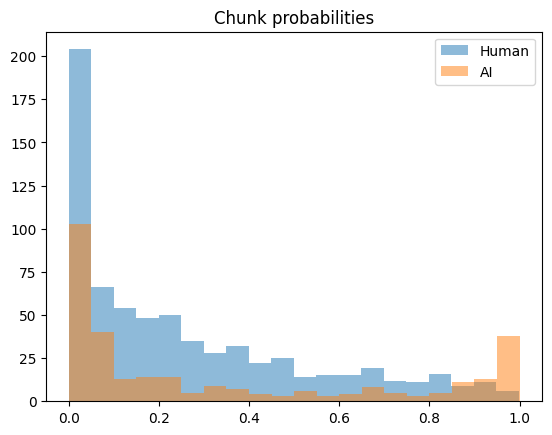

ROC AUC: 0.51667479918925
Suggested threshold: 0.852


In [11]:
from tqdm import tqdm
from itertools import chain

sentence_model = joblib.load("sentence_rf_detector.joblib")
chunk_model    = joblib.load("chunk_rf_detector.joblib")

scaler_sentence = joblib.load("scaler_sentence_rf.joblib")
scaler_chunk    = joblib.load("scaler_chunk_rf.joblib")

val_results = []

for row in tqdm(validation_set.itertuples(index=False), total=len(validation_set)):
    text = row.text
    pythia_logprobs = np.array(row.pythia_logprobs)
    gpt2_logprobs   = np.array(row.gpt2_logprobs)
    label = row.label

    results = get_features(pythia_logprobs, gpt2_logprobs, text)
    results = results.reshape(1, -1) 
    Xc = scaler_chunk.transform(results)
    prob = chunk_model.predict_proba(Xc)[0, 1]


    val_results.append({
        "essay": text,
        "label": label,
        "chunk_prob": float(prob)
    })

import matplotlib.pyplot as plt

human_probs = [r["chunk_prob"] for r in val_results if r["label"] == 0]
ai_probs    = [r["chunk_prob"] for r in val_results if r["label"] == 1]

plt.hist(human_probs, bins=20, alpha=0.5, label="Human")
plt.hist(ai_probs, bins=20, alpha=0.5, label="AI")
plt.legend()
plt.title("Chunk probabilities")
plt.show()

from sklearn.metrics import roc_curve

# Flatten sentence probs & labels
y_true = []
y_scores = []

from sklearn.metrics import roc_curve, auc

y_true = [r["label"] for r in val_results]
y_scores = [r["chunk_prob"] for r in val_results]

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

best_idx = (tpr - fpr).argmax()
threshold = thresholds[best_idx]

print("ROC AUC:", roc_auc)
print("Suggested threshold:", threshold)

from sklearn.isotonic import IsotonicRegression

ir = IsotonicRegression(out_of_bounds="clip")
ir.fit(y_scores, y_true)

calibrated_scores = ir.transform(y_scores)

In [ ]:
print("Computing features...")


	
for row in tqdm(text.itertuples(index=False), total=len(text)):
    essay = row[0]
    label = row[1]

    chunks = make_sentence_chunks(essay, window=4, stride=2)

    for chunk in chunks:
        sentences = split_sentences_max_words(chunk)

        # ====== YOUR EXISTING FEATURE PIPELINE ======
        sent_feats = compute_stats_features(sentences)  # mean_len, std_len, etc

        features = {}
        model_features = {}
        all_word_log_probs_dict = {}

        for name, lm in lm_models.items():
            sentence_word_log_probs = []
            features_list = []

            for s in sentences:
                if len(lm.tokenize(s)) >= 1024:
                    continue

                tokens, token_log_probs = get_token_logprobs_and_tokens(lm, s)
                _, word_log_probs = tokens_to_word_logprobs(tokens, token_log_probs)

                if len(word_log_probs) == 0:
                    continue

                features_list.append(extract_word_features(word_log_probs))
                sentence_word_log_probs.append(word_log_probs)

            if len(features_list) == 0:
                continue

            all_word_log_probs = np.concatenate(sentence_word_log_probs)
            all_word_log_probs_dict[name] = all_word_log_probs

            model_features[name] = np.mean(features_list, axis=0)

            burstiness = np.mean([
                lm.get_burstiness(lp.flatten())
                for lp in sentence_word_log_probs
            ])

            intra_var = np.var(all_word_log_probs)

            features[name] = np.concatenate([
                model_features[name],
                [intra_var, burstiness]
            ])

        # require both LMs
        if "gpt2" not in features or "pythia" not in features:
            continue

        disagree_val = cross_model_disagreement(
            all_word_log_probs_dict["gpt2"],
            all_word_log_probs_dict["pythia"]
        )

        lm_feats = np.concatenate([features["gpt2"], features["pythia"]])
        feats = np.concatenate([lm_feats, [disagree_val], sent_feats])

        X.append(feats)
        y.append(label)
    
    
    # Skip if no sentences were processed (all too long or empty)

    
    #total_len = full_tokens["gpt2"].size(1)

    #chunks = sliding_window_chunks(word_tokens["gpt2"][0], 300, 50)


    #for idx in range(len(sentences)): 
    #    chunk_text = chunks[idx]

        # Get log probs from both models
        #gpt2_log_probs = lm_gpt2.get_log_probs(chunk_text)
        #opt_log_probs = lm_opt.get_log_probs(chunk_text)

        # Extract features from each LM
     #   feats_gpt2 = extract_features(gpt2_log_probs) 
    #  feats_opt = extract_features(opt_log_probs)  # Fixed: was using gpt2_log_probs

        # Compute cross-model disagreement
        #disagree = cross_model_disagreement(gpt2_log_probs, opt_log_probs)  # Fixed: pass log-probs, not LM objects
        #if disagree is None: 
        #    disagree = 0.0

        # Get burstiness
        #burstiness_val = lm_gpt2.get_burstiness(gpt2_log_probs) 
        #burstiness_val = np.clip(burstiness_val, 0, 5)
#
        ## Get intra-sentence variance (using sentence info from full text)
        ## For chunk, estimate using variance of log-probs
        #intra_var = np.clip(np.var(gpt2_log_probs), 0, 5)  # Simplified: use variance
#
        #disagree = np.clip(disagree, 0, 10)
#
        ## Combine all features
        #lm_feats = np.concatenate([feats_gpt2, feats_opt]) 


#X, y = batched_hybrid_pipeline(text, lm_models, chunk_size=128, stride=64, batch_size=16)
#print(X.shape, y.shape)

X, y = np.vstack(X), np.array(y)
X, y = shuffle(X, y, random_state=42)

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "scaler.joblib")

model = EssayAIDetector()

model.fit(X_train, y_train)     # train on training data

base_model = model.model

 # your trained sklearn model

calibrated = CalibratedClassifierCV(
    base_model,
    method="isotonic",   # or "sigmoid"
    cv=5
)

calibrated.fit(X_train, y_train)

joblib.dump(calibrated, "hybrid_3m_chunk_detector.joblib")

print("Classes:", model.model.classes_)
print("✅ Training complete. Model saved as detector_model.npz")

y_pred = calibrated.predict(X_test)
y_proba = calibrated.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Human", "AI"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



feature_names = (
    [f"gpt2_{n}" for n in ["mean","var","std","p90","p10","len","intra","burst"]] +
    [f"opt_{n}"  for n in ["mean","var","std","p90","p10","len","intra","burst"]] +
    ["disagree", "mean_len", "std_len", "mean_rep", "max_rep"]
)

assert X.shape[1] == len(feature_names)


print("Feature dim:", X.shape[1])
print("Feature names:", len(feature_names))

r = permutation_importance(
    calibrated,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importances = sorted(
    zip(feature_names, r.importances_mean),
    key=lambda x: x[1],
    reverse=True
)

print("\nFeature importance (permutation):")
for name, score in importances:
    print(f"{name:25s} {score:.4f}")
	

probs = calibrated.predict_proba(X_train)[:,1]

thresholds = np.linspace(0.1, 0.9, 81)
best_t, best_f1 = 0.5, 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Chosen threshold:", best_t)

# apply to test
y_pred = (y_proba >= best_t).astype(int)

100%|██████████| 3607/3607 [00:00<00:00, 32963.99it/s]


Computing features...


 53%|█████▎    | 22725/43194 [2:04:22<1:52:01,  3.05it/s]


KeyboardInterrupt: 

In [ ]:
## sentence level predictions

lm_gpt2 = LMLogProbs("gpt2-medium")
lm_opt  = LMLogProbs("facebook/opt-125m")
#lm_gpt3 = LMLogProbs("EleutherAI/gpt-j-6B")

data = pd.read_csv("../datasets/ai-ga-dataset.csv")
data2 = pd.read_csv("../datasets/AI-vs-Human-2500.csv", encoding='latin-1')
data3 = pd.read_csv("../datasets/AI_Human.csv")
data4 = pd.read_csv("../datasets/AI_Generated_Essays_Dataset.csv")
data5 = pd.read_excel("../datasets/AIGTxt.xlsx")

X, y = [], []

text = []
sentences_per_chunk = 3 

lm_models = {
    "gpt2": LMLogProbs("gpt2-medium"),
    "opt": LMLogProbs("facebook/opt-125m")
}

chunk_size = 300
overlap = 50

# get texts

##get

for _, row in tqdm(data.iterrows(), total=len(data)):
	text.append((row["abstract"], row["label"]))
     
for _, row in tqdm(data2.iterrows(), total=len(data2)):
	txt = row["text"]
	if isinstance(txt, str):
		text.append((txt, 1 if str(row["label"]).lower() == "fake" else 0))
          
#for _, row in tqdm(data3.iterrows(), total=len(data3)):
#	log_probs = lm.get_log_probs(row["text"])
#	feats = extract_features(log_probs)

#
#	X.append(feats)
#	y.append(row["generated"])

for _, row in tqdm(data4.iterrows(), total=len(data4)):
	text.append((row["text"], row["generated"]))
	
for _, row in tqdm(data5.iterrows(), total=len(data5)):
	text.append((row["Human-Generated"], 0))
	text.append((row["ChatGPT-Generated"], 1))
	



#print("Computing features...")



print("Computing features...")

text = pd.DataFrame(text)
	
for row in tqdm(text.itertuples(index=False), total=len(text)):
    essay = row[0]
    label = row[1]

    chunks = make_sentence_chunks(essay, window=4, stride=2)

    for chunk in chunks:
        sentences = split_sentences_max_words(chunk)

        # ====== YOUR EXISTING FEATURE PIPELINE ======
        sent_feats = compute_stats_features(sentences)  # mean_len, std_len, etc

        features = {}
        model_features = {}
        all_word_log_probs_dict = {}

        for name, lm in lm_models.items():
            sentence_word_log_probs = []
            features_list = []

            for s in sentences:
                if len(lm.tokenize(s)) >= 1024:
                    continue

                tokens, token_log_probs = get_token_logprobs_and_tokens(lm, s)
                _, word_log_probs = tokens_to_word_logprobs(tokens, token_log_probs)

                if len(word_log_probs) == 0:
                    continue

                features_list.append(extract_word_features(word_log_probs))
                sentence_word_log_probs.append(word_log_probs)

            if len(features_list) == 0:
                continue

            all_word_log_probs = np.concatenate(sentence_word_log_probs)
            all_word_log_probs_dict[name] = all_word_log_probs

            model_features[name] = np.mean(features_list, axis=0)

            burstiness = np.mean([
                lm.get_burstiness(lp.flatten())
                for lp in sentence_word_log_probs
            ])

            intra_var = np.var(all_word_log_probs)

            features[name] = np.concatenate([
                model_features[name],
                [intra_var, burstiness]
            ])

        # require both LMs
        if "gpt2" not in features or "opt" not in features:
            continue

        disagree_val = cross_model_disagreement(
            all_word_log_probs_dict["gpt2"],
            all_word_log_probs_dict["opt"]
        )

        lm_feats = np.concatenate([features["gpt2"], features["opt"]])
        feats = np.concatenate([lm_feats, [disagree_val], sent_feats])

        X.append(feats)
        y.append(label)
    
    
    # Skip if no sentences were processed (all too long or empty)

    
    #total_len = full_tokens["gpt2"].size(1)

    #chunks = sliding_window_chunks(word_tokens["gpt2"][0], 300, 50)


    #for idx in range(len(sentences)): 
    #    chunk_text = chunks[idx]

        # Get log probs from both models
        #gpt2_log_probs = lm_gpt2.get_log_probs(chunk_text)
        #opt_log_probs = lm_opt.get_log_probs(chunk_text)

        # Extract features from each LM
     #   feats_gpt2 = extract_features(gpt2_log_probs) 
    #  feats_opt = extract_features(opt_log_probs)  # Fixed: was using gpt2_log_probs

        # Compute cross-model disagreement
        #disagree = cross_model_disagreement(gpt2_log_probs, opt_log_probs)  # Fixed: pass log-probs, not LM objects
        #if disagree is None: 
        #    disagree = 0.0

        # Get burstiness
        #burstiness_val = lm_gpt2.get_burstiness(gpt2_log_probs) 
        #burstiness_val = np.clip(burstiness_val, 0, 5)
#
        ## Get intra-sentence variance (using sentence info from full text)
        ## For chunk, estimate using variance of log-probs
        #intra_var = np.clip(np.var(gpt2_log_probs), 0, 5)  # Simplified: use variance
#
        #disagree = np.clip(disagree, 0, 10)
#
        ## Combine all features
        #lm_feats = np.concatenate([feats_gpt2, feats_opt]) 


#X, y = batched_hybrid_pipeline(text, lm_models, chunk_size=128, stride=64, batch_size=16)
#print(X.shape, y.shape)

X, y = np.vstack(X), np.array(y)
X, y = shuffle(X, y, random_state=42)

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "scaler.joblib")

model = EssayAIDetector()

model.fit(X_train, y_train)     # train on training data

base_model = model.model

 # your trained sklearn model

calibrated = CalibratedClassifierCV(
    base_model,
    method="isotonic",   # or "sigmoid"
    cv=5
)

calibrated.fit(X_train, y_train)

joblib.dump(calibrated, "hybrid_lm_chunk_detector.joblib")

print("Classes:", model.model.classes_)
print("✅ Training complete. Model saved as detector_model.npz")

y_pred = calibrated.predict(X_test)
y_proba = calibrated.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Human", "AI"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



feature_names = (
    [f"gpt2_{n}" for n in ["mean","var","std","p90","p10","len","intra","burst"]] +
    [f"opt_{n}"  for n in ["mean","var","std","p90","p10","len","intra","burst"]] +
    ["disagree", "mean_len", "std_len", "mean_rep", "max_rep"]
)

assert X.shape[1] == len(feature_names)


print("Feature dim:", X.shape[1])
print("Feature names:", len(feature_names))

r = permutation_importance(
    calibrated,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importances = sorted(
    zip(feature_names, r.importances_mean),
    key=lambda x: x[1],
    reverse=True
)

print("\nFeature importance (permutation):")
for name, score in importances:
    print(f"{name:25s} {score:.4f}")
	

probs = calibrated.predict_proba(X_train)[:,1]

thresholds = np.linspace(0.1, 0.9, 81)
best_t, best_f1 = 0.5, 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Chosen threshold:", best_t)

# apply to test
y_pred = (y_proba >= best_t).astype(int)

100%|██████████| 3607/3607 [00:00<00:00, 32672.75it/s]


Computing features...


100%|██████████| 43194/43194 [2:58:56<00:00,  4.02it/s]   


Classes: [0 1]
✅ Training complete. Model saved as detector_model.npz

Accuracy: 0.8393060080309115
ROC AUC: 0.879131638538577

Classification Report:
              precision    recall  f1-score   support

       Human       0.83      0.93      0.88      8253
          AI       0.86      0.68      0.76      4946

    accuracy                           0.84     13199
   macro avg       0.85      0.81      0.82     13199
weighted avg       0.84      0.84      0.83     13199


Confusion Matrix:
[[7700  553]
 [1568 3378]]
Feature dim: 21
Feature names: 21

Feature importance (permutation):
opt_mean                  0.2589
mean_rep                  0.1735
gpt2_mean                 0.1685
gpt2_len                  0.1423
gpt2_p10                  0.0899
opt_len                   0.0800
mean_len                  0.0800
gpt2_std                  0.0769
opt_intra                 0.0287
opt_var                   0.0156
opt_std                   0.0150
gpt2_intra                0.0124
gpt2_p90   

In [ ]:
## sentence level predictions

lm_gpt2 = LMLogProbs("gpt2-medium")
lm_opt  = LMLogProbs("facebook/opt-125m")
#lm_gpt3 = LMLogProbs("EleutherAI/gpt-j-6B")

data = pd.read_csv("../datasets/ai-ga-dataset.csv")
data2 = pd.read_csv("../datasets/AI-vs-Human-2500.csv", encoding='latin-1')
data3 = pd.read_csv("../datasets/AI_Human.csv")
data4 = pd.read_csv("../datasets/AI_Generated_Essays_Dataset.csv")
data5 = pd.read_excel("../datasets/AIGTxt.xlsx")

X, y = [], []

text = []


for _, row in tqdm(data.iterrows(), total=len(data)):
	text.append((row["abstract"], row["label"]))
     
for _, row in tqdm(data2.iterrows(), total=len(data2)):
	txt = row["text"]
	if isinstance(txt, str):
		text.append((txt, 1 if str(row["label"]).lower() == "fake" else 0))
          
#for _, row in tqdm(data3.iterrows(), total=len(data3)):
#	log_probs = lm.get_log_probs(row["text"])
#	feats = extract_features(log_probs)

#
#	X.append(feats)
#	y.append(row["generated"])

for _, row in tqdm(data4.iterrows(), total=len(data4)):
	text.append((row["text"], row["generated"]))
	
for _, row in tqdm(data5.iterrows(), total=len(data5)):
	text.append((row["Human-Generated"], 0))
	text.append((row["ChatGPT-Generated"], 1))
	



#print("Computing features...")


lm_models = {
    "gpt2": LMLogProbs("gpt2-medium"),
    "opt":  LMLogProbs("facebook/opt-125m"),
}
text = pd.DataFrame(text)
print("Building sentence-level dataset...")
counter = 0

for row in tqdm(text.itertuples(index=False), total=len(text)):
    essay = row[0]
    label = row[1]

    sentences = split_sentences_max_words(essay)

    for s in sentences:
        if not isinstance(s, str):
            continue

        # skip very short junk
        if len(s.split()) < 5:
            continue

        sent_feats = sentence_stats_features(s)  
        # returns: [mean_len, std_len, mean_rep, max_rep]

        features = {}
        all_word_log_probs_dict = {}
        
        for name, lm in lm_models.items():
            if len(lm.tokenize(s)) >= 1024:
                counter += 1
                print("sentence too large, dropped" + counter)
                continue

            tokens, token_log_probs = get_token_logprobs_and_tokens(lm, s)
            _, word_log_probs = tokens_to_word_logprobs(tokens, token_log_probs)

            if len(word_log_probs) == 0:
                continue

            base_feats = extract_word_features(word_log_probs)
            intra_var = np.clip(np.var(word_log_probs), 0, 5)
            burst = np.clip(lm.get_burstiness(word_log_probs.flatten()), 0, 5)

            features[name] = np.concatenate([base_feats, [intra_var, burst]])
            all_word_log_probs_dict[name] = word_log_probs

        # require BOTH LMs
        if "gpt2" not in features or "opt" not in features:
            continue

        disagree = cross_model_disagreement(
            all_word_log_probs_dict["gpt2"],
            all_word_log_probs_dict["opt"]
        )

        lm_feats = np.concatenate([features["gpt2"], features["opt"]])
        feat_vec = np.concatenate([lm_feats, [disagree], sent_feats])

        X.append(feat_vec)
        y.append(label)

X = np.vstack(X)
y = np.array(y)

print("Sentence samples:", X.shape)

X, y = np.vstack(X), np.array(y)
X, y = shuffle(X, y, random_state=42)

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "scaler.joblib")

model = EssayAIDetector()

model.fit(X_train, y_train)     # train on training data

base_model = model.model

 # your trained sklearn model

calibrated = CalibratedClassifierCV(
    base_model,
    method="isotonic",   # or "sigmoid"
    cv=5
)

calibrated.fit(X_train, y_train)

joblib.dump(calibrated, "hybrid_lm_sentence_detector.joblib")

print("Classes:", model.model.classes_)
print("✅ Training complete. Model saved as detector_model.npz")

y_pred = calibrated.predict(X_test)
y_proba = calibrated.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Human", "AI"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



feature_names = (
    [f"gpt2_{n}" for n in ["mean","var","std","p90","p10","len","intra","burst"]] +
    [f"opt_{n}"  for n in ["mean","var","std","p90","p10","len","intra","burst"]] +
    ["disagree", "mean_len", "std_len", "mean_rep", "max_rep"]
)

assert X.shape[1] == len(feature_names)


print("Feature dim:", X.shape[1])
print("Feature names:", len(feature_names))

r = permutation_importance(
    calibrated,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importances = sorted(
    zip(feature_names, r.importances_mean),
    key=lambda x: x[1],
    reverse=True
)

print("\nFeature importance (permutation):")
for name, score in importances:
    print(f"{name:25s} {score:.4f}")
	

probs = calibrated.predict_proba(X_train)[:,1]

thresholds = np.linspace(0.1, 0.9, 81)
best_t, best_f1 = 0.5, 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Chosen threshold:", best_t)

# apply to test
y_pred = (y_proba >= best_t).astype(int)

100%|██████████| 3607/3607 [00:00<00:00, 31252.60it/s]


Building sentence-level dataset...


100%|██████████| 43194/43194 [2:51:40<00:00,  4.19it/s]   


Sentence samples: (236103, 21)
Classes: [0 1]
✅ Training complete. Model saved as detector_model.npz

Accuracy: 0.7361343470066284
ROC AUC: 0.7887338971326519

Classification Report:
              precision    recall  f1-score   support

       Human       0.74      0.83      0.78     27001
          AI       0.73      0.61      0.66     20220

    accuracy                           0.74     47221
   macro avg       0.73      0.72      0.72     47221
weighted avg       0.74      0.74      0.73     47221


Confusion Matrix:
[[22417  4584]
 [ 7876 12344]]
Feature dim: 21
Feature names: 21

Feature importance (permutation):
opt_mean                  0.1835
gpt2_mean                 0.1075
gpt2_std                  0.0945
opt_std                   0.0879
mean_rep                  0.0844
opt_var                   0.0378
max_rep                   0.0209
gpt2_var                  0.0202
gpt2_p10                  0.0182
gpt2_len                  0.0177
gpt2_intra                0.0108
opt_p10 

In [ ]:
lm_gpt2 = LMLogProbs("gpt2-medium")
lm_opt  = LMLogProbs("facebook/opt-125m")
#lm_gpt3 = LMLogProbs("EleutherAI/gpt-j-6B")

data = pd.read_csv("../datasets/ai-ga-dataset.csv")
data2 = pd.read_csv("../datasets/AI-vs-Human-2500.csv", encoding='latin-1')
data3 = pd.read_csv("../datasets/AI_Human.csv")
data4 = pd.read_csv("../datasets/AI_Generated_Essays_Dataset.csv")
data5 = pd.read_excel("../datasets/AIGTxt.xlsx").head(2000)

X, y = [], []

text = []
sentences_per_chunk = 3 

lm_models = {
    "gpt2": LMLogProbs("gpt2-medium"),
    "opt": LMLogProbs("facebook/opt-125m")
}

chunk_size = 300
overlap = 50

# get texts

##get

for _, row in tqdm(data.iterrows(), total=len(data)):
	text.append((row["abstract"], row["label"]))
     
for _, row in tqdm(data2.iterrows(), total=len(data2)):
	txt = row["text"]
	if isinstance(txt, str):
		text.append((txt, 1 if str(row["label"]).lower() == "fake" else 0))
          
#for _, row in tqdm(data3.iterrows(), total=len(data3)):
#	log_probs = lm.get_log_probs(row["text"])
#	feats = extract_features(log_probs)

#
#	X.append(feats)
#	y.append(row["generated"])

for _, row in tqdm(data4.iterrows(), total=len(data4)):
	text.append((row["text"], row["generated"]))
	
for _, row in tqdm(data5.iterrows(), total=len(data5)):
	text.append((row["Human-Generated"], 0))
	text.append((row["ChatGPT-Generated"], 1))
	



#print("Computing features...")



print("Computing features...")

text = pd.DataFrame(text)
	
for row in tqdm(text.itertuples(index=False), total=len(text)):
    text_input = row[0]
    label = row[1]

    sentences = split_sentences_max_words(text_input)

    #get sentence level features
    if len(sentences) < 2:
        sent_feats = np.zeros(4)
    else:
        lengths = [len(s.split()) for s in sentences]
        std_len = float(np.std(lengths)/np.mean(lengths)) if np.mean(lengths)>0 else 0.0
        mean_len = float(np.mean(lengths))

        rep_counts = []
        for s in sentences:
                words = s.split()
                c = Counter(words)
                rep_counts.append(max(c.values()))

        mean_rep = float(np.mean(rep_counts))
        max_rep = float(np.max(rep_counts))
        sent_feats = np.array([mean_len, std_len, mean_rep, max_rep])


    

    
    #tokenized_chunks = {}  # dictionary per LM
    #for name in lm_models:
    #    tokenized_chunks[name] = combine_sentence_tokens(
    #        tokenized_sentences[name]
    #    )

    
    #if not tokenized_chunks:
    #    continue
#
    #chunk_features_per_lm = {name: [] for name in lm_models}

    word_tokens = {}
    sentence_word_log_probs = {}
    features = {}
    disagree = {}
    model_features = {}
    all_word_log_probs_dict = {}

    for name, lm in lm_models.items():

        word_tokens[name] = []
        sentence_word_log_probs[name] = []
        features_list = []

        for s in sentences:
            # use TOKEN length, not char length
            if len(lm.tokenize(s)) >= 1024:
                continue

            tokens, token_log_probs = get_token_logprobs_and_tokens(lm, s)
            word_strs, word_log_probs = tokens_to_word_logprobs(tokens, token_log_probs)

            if len(word_log_probs) == 0:
                continue

            feat = extract_word_features(word_log_probs)
            features_list.append(feat)

            sentence_word_log_probs[name].append(word_log_probs)

        # if this LM produced nothing → skip it
        if len(sentence_word_log_probs[name]) == 0 or len(features_list) == 0:
            continue

        all_word_log_probs = np.concatenate(sentence_word_log_probs[name])
        all_word_log_probs_dict[name] = all_word_log_probs

        model_features[name] = np.mean(features_list, axis=0)

        burstiness_vals = [
            lm.get_burstiness(lp.flatten())
            for lp in sentence_word_log_probs[name]
        ]
        burstiness_val = np.clip(np.mean(burstiness_vals), 0, 5)

        intra_var = np.clip(np.var(all_word_log_probs), 0, 5)

        features[name] = np.concatenate([
            model_features[name],
            [intra_var, burstiness_val]
        ])


    # ---- after LM loop ----

    # require BOTH models
    if "gpt2" not in features or "opt" not in features:
        continue

    if "gpt2" in all_word_log_probs_dict and "opt" in all_word_log_probs_dict:
        disagree_val = cross_model_disagreement(
            all_word_log_probs_dict["gpt2"],
            all_word_log_probs_dict["opt"]
        )
    else:
        disagree_val = 0.0

    lm_feats = np.concatenate([
        features["gpt2"],
        features["opt"]
    ])

    feats = np.concatenate([lm_feats, [disagree_val], sent_feats])

    X.append(feats)
    y.append(label)
    
    # Skip if no sentences were processed (all too long or empty)

    
    #total_len = full_tokens["gpt2"].size(1)

    #chunks = sliding_window_chunks(word_tokens["gpt2"][0], 300, 50)


    #for idx in range(len(sentences)): 
    #    chunk_text = chunks[idx]

        # Get log probs from both models
        #gpt2_log_probs = lm_gpt2.get_log_probs(chunk_text)
        #opt_log_probs = lm_opt.get_log_probs(chunk_text)

        # Extract features from each LM
     #   feats_gpt2 = extract_features(gpt2_log_probs) 
    #  feats_opt = extract_features(opt_log_probs)  # Fixed: was using gpt2_log_probs

        # Compute cross-model disagreement
        #disagree = cross_model_disagreement(gpt2_log_probs, opt_log_probs)  # Fixed: pass log-probs, not LM objects
        #if disagree is None: 
        #    disagree = 0.0

        # Get burstiness
        #burstiness_val = lm_gpt2.get_burstiness(gpt2_log_probs) 
        #burstiness_val = np.clip(burstiness_val, 0, 5)
#
        ## Get intra-sentence variance (using sentence info from full text)
        ## For chunk, estimate using variance of log-probs
        #intra_var = np.clip(np.var(gpt2_log_probs), 0, 5)  # Simplified: use variance
#
        #disagree = np.clip(disagree, 0, 10)
#
        ## Combine all features
        #lm_feats = np.concatenate([feats_gpt2, feats_opt]) 


#X, y = batched_hybrid_pipeline(text, lm_models, chunk_size=128, stride=64, batch_size=16)
#print(X.shape, y.shape)

X, y = np.vstack(X), np.array(y)
X, y = shuffle(X, y, random_state=42)

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "scaler.joblib")

model = EssayAIDetector()

model.fit(X_train, y_train)     # train on training data

base_model = model.model

 # your trained sklearn model

calibrated = CalibratedClassifierCV(
    base_model,
    method="isotonic",   # or "sigmoid"
    cv=5
)

calibrated.fit(X_train, y_train)

joblib.dump(calibrated, "hybrid_lm_detector-v1.joblib")

print("Classes:", model.model.classes_)
print("✅ Training complete. Model saved as detector_model.npz")

y_pred = calibrated.predict(X_test)
y_proba = calibrated.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Human", "AI"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



feature_names = (
    [f"gpt2_{n}" for n in ["mean","var","std","p90","p10","len","intra","burst"]] +
    [f"opt_{n}"  for n in ["mean","var","std","p90","p10","len","intra","burst"]] +
    ["disagree", "mean_len", "std_len", "mean_rep", "max_rep"]
)

assert X.shape[1] == len(feature_names)


print("Feature dim:", X.shape[1])
print("Feature names:", len(feature_names))

r = permutation_importance(
    calibrated,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importances = sorted(
    zip(feature_names, r.importances_mean),
    key=lambda x: x[1],
    reverse=True
)

print("\nFeature importance (permutation):")
for name, score in importances:
    print(f"{name:25s} {score:.4f}")
	

probs = calibrated.predict_proba(X_train)[:,1]

thresholds = np.linspace(0.1, 0.9, 81)
best_t, best_f1 = 0.5, 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Chosen threshold:", best_t)

# apply to test
y_pred = (y_proba >= best_t).astype(int)

KeyboardInterrupt: 

In [ ]:
lm_gpt2 = LMLogProbs("distilgpt2") 
lm_opt = LMLogProbs("facebook/opt-125m") 

data = pd.read_csv("../datasets/ai-ga-dataset.csv") 
data2 = pd.read_csv("../datasets/AI-vs-Human-2500.csv", encoding='latin-1') 
data3 = pd.read_csv("../datasets/AI_Human.csv") 
data4 = pd.read_csv("../datasets/AI_Generated_Essays_Dataset.csv") 
data5 = pd.read_excel("../datasets/AIGTxt.xlsx") 

X, y = [], [] 
text = [] # get texts ##get 
for _, row in tqdm(data4.iterrows(), total=len(data4)): 
    text.append((row["text"], row["generated"])) 

for _, row in data5.iterrows(): 
    text.append((row["Human-Generated"], 0)) 
    text.append((row["ChatGPT-Generated"], 1)) 

for _, row in tqdm(data3.iterrows(), total=len(data3)): 
    log_probs = lm.get_log_probs(row["text"]) 
    feats = extract_features(log_probs) 
    X.append(feats) 
    y.append(row["generated"]) 

for _, row in tqdm(data.iterrows(), total=len(data)): 
    text.append((row["abstract"], row["label"])) #

for _, row in tqdm(data2.iterrows(), total=len(data2)): 
    txt = row["text"] 
    if isinstance(txt, str): 
        text.append((txt, 1 if str(row["label"]).lower() == "fake" else 0)) 


print("Computing features...") 

text = pd.DataFrame(text) 

for row in tqdm(text.itertuples(index=False), total=len(text)):
    text_input = row[0] 
    label = row[1] 
    
    lp_gpt2Probs = lm_gpt2.get_log_probs(text_input) 
    lp_optprobs = lm_opt.get_log_probs(text_input) 
    
    feats = extract_features(lp_gpt2Probs) 

    repeatingWords = lm_gpt2.get_repeating_words(text_input) 
    sentenceLength = lm_gpt2.get_sentence_length(text_input) 
    burstiness = lm_gpt2.get_sentence_burstiness(text_input, lp_gpt2Probs) 
    intra_var = lm_gpt2.get_intra_sentence_token_variance(text_input, lp_gpt2Probs) 
    burstiness = np.clip(burstiness, 0, 5) 
    intra_var = np.clip(intra_var, 0, 5) 
    disagree = cross_model_disagreement(lp_gpt2Probs, lp_optprobs) 
    disagree = np.clip(disagree, 0, 10) 
    feats = np.append(feats, [intra_var, disagree, burstiness, repeatingWords, sentenceLength]) 
    X.append(feats) 
    y.append(label)

X, y = shuffle(X, y, random_state=42) # train / test split 
    
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y ) 
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test) 
joblib.dump(scaler, "scaler.joblib") 
X, y = np.vstack(X), np.array(y) 
model = EssayAIDetector() 
base_model = EssayAIDetector().model # your trained sklearn model 

calibrated = CalibratedClassifierCV( 
    base_model, 
    method="isotonic", #or "sigmoid" 
    cv=5 ) 

calibrated.fit(X_train, y_train) 
joblib.dump(calibrated, "calibrated_detector.joblib") 
print("Classes:", model.model.classes_) 
print("✅ Training complete. Model saved as detector_model.npz") 
y_pred = model.model.predict(X_test) 
y_proba = model.model.predict_proba(X_test)[:, 1] 
print("\nAccuracy:", accuracy_score(y_test, y_pred)) 
print("ROC AUC:", roc_auc_score(y_test, y_proba)) 
print("\nClassification Report:") 
print(classification_report(y_test, y_pred, target_names=["Human", "AI"])) 
print("\nConfusion Matrix:") 
print(confusion_matrix(y_test, y_pred)) 
feature_names = ( 
    ["mean,", 
     "variance", 
     "standard_deviation", 
     "90th_percentile", 
     "10th_percentile", 
     "doc_length", "intra_var", 
     "disagree", "burstiness", 
     "repeating_words", 
     "sentence_length"] ) 
r = permutation_importance( model.model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1 ) 
importances = sorted( zip(feature_names, r.importances_mean), key=lambda x: x[1], reverse=True ) 
print("\nFeature importance (permutation):") 
for name, score in importances: 
    print(f"{name:25s} {score:.4f}") 
    thresholds = np.linspace(0.1, 0.9, 81) 
    best_t, best_f1 = 0.5, 0 
    for t in thresholds: preds = (y_proba >= t).astype(int) 
    f1 = f1_score(y_test, preds) 
    if f1 > best_f1: 
        best_f1 = f1 
        best_t = t 
    print(f"Best threshold: {best_t:.2f}, F1: {best_f1:.4f}")

KeyboardInterrupt: 

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

probs = model.predict_proba(X_val)[:,1]

prob_true, prob_pred = calibration_curve(y_val, probs, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted prob")
plt.ylabel("True prob")
plt.show()

NameError: name 'X_val' is not defined

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

def batched_hybrid_pipeline(text_df, lm_models, chunk_size=128, stride=64, batch_size=16):
    """
    lm_models: dict of name -> LMLogProbs instance
    text_df: dataframe with columns [text, label]
    batch_size: number of chunks per batch to send through LM
    """
    X, y = [], []

    for row in tqdm(text_df.itertuples(index=False), total=len(text_df)):
        text_input = row[0]
        label = row[1]

        # -------------------------
        # 1️⃣ Sentence-level features (style)
        # -------------------------
        sentences = [s.strip() for s in text_input.split('.') if s.strip()]
        if len(sentences) < 2:
            sent_feats = np.zeros(4)
        else:
            lengths = [len(s.split()) for s in sentences]
            std_len = float(np.std(lengths)/np.mean(lengths)) if np.mean(lengths)>0 else 0.0
            mean_len = float(np.mean(lengths))
            # crude repetition measure (replace with your LM function if needed)
            rep_counts = [s.split().count(s.split()[0]) for s in sentences]
            mean_rep = float(np.mean(rep_counts))
            max_rep = float(np.max(rep_counts))
            sent_feats = np.array([mean_len, std_len, mean_rep, max_rep])

        # -------------------------
        # 2️⃣ Split into chunks
        # -------------------------
        chunks = sliding_window_chunks(text_input, chunk_size, stride)
        if len(chunks) == 0:
            continue

        # -------------------------
        # 3️⃣ Tokenize all chunks per LM (once)
        # -------------------------
        tokenized_chunks = {}
        for name, lm in lm_models.items():
            tokenized_chunks[name] = [lm.tokenize(c) for c in chunks]

        # -------------------------
        # 4️⃣ Batch LM forward passes per LM
        # -------------------------
        chunk_features_per_lm = {name: [] for name in lm_models}

        for name, lm in lm_models.items():
            tok_chunks = tokenized_chunks[name]
            for i in range(0, len(tok_chunks), batch_size):
                batch = torch.cat(tok_chunks[i:i+batch_size], dim=0)  # batch_dim
                with torch.no_grad():
                    lp_batch = lm.get_log_probs(batch)  # should return shape [batch_size, seq_len]

                # compute LM features per chunk
                for j, lp in enumerate(lp_batch):
                    feats = extract_features(lp)
                    burst = np.clip(lm.get_sentence_burstiness(tok_chunks[i+j], lp), 0, 5)
                    intra_var = np.clip(lm.get_intra_sentence_token_variance(tok_chunks[i+j], lp), 0, 5)
                    chunk_features_per_lm[name].append(np.concatenate([feats, [intra_var, burst]]))

        # -------------------------
        # 5️⃣ Compute cross-model disagreement per chunk
        # -------------------------
        chunk_disagree = []
        names = list(lm_models.keys())
        for idx in range(len(chunks)):
            for i in range(len(names)):
                for j in range(i+1, len(names)):
                    lp_a = tokenized_chunks[names[i]][idx]
                    lp_b = tokenized_chunks[names[j]][idx]
                    disagree = np.clip(cross_model_disagreement(lp_a, lp_b), 0, 10)
                    chunk_disagree.append(disagree)

        # -------------------------
        # 6️⃣ Combine chunk + sentence features
        # -------------------------
        for idx in range(len(chunks)):
            lm_feats_all = np.concatenate([chunk_features_per_lm[name][idx] for name in names])
            # get disagreement features for this chunk
            # if N models, num pairs = N*(N-1)/2
            start = idx * len(chunk_disagree)//len(chunks)
            end = start + len(chunk_disagree)//len(chunks)
            disagree_feats = np.array(chunk_disagree[start:end])
            feats = np.concatenate([lm_feats_all, disagree_feats, sent_feats])
            X.append(feats)
            y.append(label)

    return np.array(X), np.array(y)

In [ ]:
# Assuming you have trained the model and have X_test, y_test
# For demonstration, using training data (not ideal, but for visualization)

# Load the model
detector = EssayAIDetector()
detector.load("distilgpt2_model.joblib")

# Load data for plotting
data = pd.read_csv("../datasets/ai-ga-dataset.csv")
lm = LMLogProbs("distilgpt2")

data4 = pd.read_excel("../datasets/AIGTxt.xlsx")

X, y = [], []

for _, row in data4.iterrows():
	log_probs = lm.get_log_probs(row["Human-Generated"])
	feats = extract_features(log_probs)
	repeatingWords = lm.get_repeating_words(row["Human-Generated"])
	sentenceLength = lm.get_sentence_length(row["Human-Generated"])
	feats = np.append(feats, [repeatingWords, sentenceLength])
	X.append(feats)
	y.append(0)
	
	log_probs = lm.get_log_probs(row["ChatGPT-Generated"])
	feats = extract_features(log_probs)
	repeatingWords = lm.get_repeating_words(row["ChatGPT-Generated"])
	sentenceLength = lm.get_sentence_length(row["ChatGPT-Generated"])
	feats = np.append(feats, [repeatingWords, sentenceLength])
	X.append(feats)
	y.append(1)
	
X = np.array(X)
y = np.array(y)

# Get predicted probabilities
y_proba = detector.predict_proba(X)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from get_logprobs import LMLogProbs
from detector import extract_features, EssayAIDetector
import numpy as np
import joblib

detector = EssayAIDetector()

lm_models = {
    "gpt2": LMLogProbs("gpt2-medium"),
    "opt": LMLogProbs("facebook/opt-125m")
}
scaler = joblib.load("scaler.joblib")

LOW = 0.46
HIGH = 0.54

while True:
    text = input("\nPaste an essay (or 'quit'): ")
    if text.strip().lower() == "quit":
        break

    # --- logprobs from both models ---
    log_probs_1 = lm1.get_log_probs(text)
    log_probs_2 = lm2.get_log_probs(text)

    # --- base features ---
    feats = extract_features(log_probs_1)

    # --- extra features ---
    burstiness = lm1.get_sentence_burstiness(text, log_probs_1)
    intra_var = lm1.get_intra_sentence_token_variance(text, log_probs_1)
    repeating = lm1.get_repeating_words(text)
    sent_len = lm1.get_sentence_length(text)

    # --- disagreement feature ---
    min_len = min(len(log_probs_1), len(log_probs_2))
    disagreement = np.mean(
        np.abs(
            np.array(log_probs_1[:min_len]) -
            np.array(log_probs_2[:min_len])
        )
    )

    feats = np.append(feats, [intra_var, disagreement, burstiness, repeating, sent_len])
    feats = feats.reshape(1, -1)

    feats = scaler.transform(feats)
    
    print("Features:", feats)
    
    print("FEATURES RAW:")
    for i, v in enumerate(feats.flatten()):
            print(i, round(float(v), 4))

    probs = detector.predict_proba(feats)[0]

    

    #print("Classes:", detector.model.classes_)
    #print("Raw probs:", detector.predict_proba(feats))
    prob_ai = probs[1]   # class 1 = AI
    prob_human = probs[0]

    print(f"Human probability: {prob_human:.3f}")
    print(f"AI probability: {prob_ai:.3f}")


    best_t = 0.75
    LOW = best_t - 0.05
    HIGH = best_t + 0.05

    if prob_ai < LOW:
        print("✅ Likely human-written")
    elif prob_ai > HIGH:
        print("⚠️ Likely AI-generated")
    else:
        print("🤔 Uncertain / mixed / reject")